### 1-Importando Bibliotecas

In [12]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix

# Reprodutibilidade
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

### Uploado do kaggle.json

In [13]:
from google.colab import files
files.upload()  # selecione o kaggle.json

import os

os.makedirs("/root/.config/kaggle", exist_ok=True)
os.rename("/content/kaggle.json", "/root/.config/kaggle/kaggle.json")
os.chmod("/root/.config/kaggle/kaggle.json", 0o600)

!kaggle datasets download -d sartajbhuvaji/brain-tumor-classification-mri -p /content/dataset --unzip


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri
License(s): MIT
100% 86.8M/86.8M [00:04<00:00, 18.4MB/s]



## 2-Reorganizar o Dataset (60/20/20)

In [14]:
KAGGLE_TRAIN_DIR = "/content/dataset/Training"
KAGGLE_TEST_DIR  = "/content/dataset/Testing"
OUTPUT_DIR       = "/content/dataset_split"

CLASSES = ["glioma_tumor", "meningioma_tumor", "no_tumor", "pituitary_tumor"]

TRAIN_RATIO = 0.60
VAL_RATIO   = 0.20
TEST_RATIO  = 0.20


def reorganize_dataset(kaggle_train, kaggle_test, output_dir, classes):
    """
    Junta Training + Testing do Kaggle, embaralha e
    redistribui em train / val / test (60/20/20).
    """
    for split in ["train", "val", "test"]:
        for cls in classes:
            os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

    for cls in classes:
        all_images = []

        # Coleta imagens de Training
        src_train = os.path.join(kaggle_train, cls)
        if os.path.exists(src_train):
            for img in os.listdir(src_train):
                all_images.append(os.path.join(src_train, img))

        # Coleta imagens de Testing
        src_test = os.path.join(kaggle_test, cls)
        if os.path.exists(src_test):
            for img in os.listdir(src_test):
                all_images.append(os.path.join(src_test, img))

        # Embaralha
        random.shuffle(all_images)

        n = len(all_images)
        n_train = int(n * TRAIN_RATIO)
        n_val   = int(n * VAL_RATIO)

        splits = {
            "train": all_images[:n_train],
            "val":   all_images[n_train:n_train + n_val],
            "test":  all_images[n_train + n_val:]
        }

        for split_name, imgs in splits.items():
            for img_path in imgs:
                dst = os.path.join(output_dir, split_name, cls, os.path.basename(img_path))
                shutil.copy(img_path, dst)

        print(f"{cls}: {n_train} treino | {n_val} validação | {n - n_train - n_val} teste")


reorganize_dataset(KAGGLE_TRAIN_DIR, KAGGLE_TEST_DIR, OUTPUT_DIR, CLASSES)

glioma_tumor: 555 treino | 185 validação | 186 teste
meningioma_tumor: 562 treino | 187 validação | 188 teste
no_tumor: 300 treino | 100 validação | 100 teste
pituitary_tumor: 540 treino | 180 validação | 181 teste


## 3-Pré-processamento e Data Augmentation

In [15]:
IMG_SIZE   = (224, 224)   # tamanho padrão para CNNs
BATCH_SIZE = 32

# Gerador de TREINO — com augmentation para aumentar diversidade
train_datagen = ImageDataGenerator(
    rescale=1./255,           # normaliza pixels para [0, 1]
    rotation_range=15,        # rotação aleatória
    width_shift_range=0.1,    # deslocamento horizontal
    height_shift_range=0.1,   # deslocamento vertical
    zoom_range=0.1,           # zoom aleatório
    horizontal_flip=True,     # espelhamento horizontal
)

# Geradores de VAL e TEST — apenas normalização, sem augmentation
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(OUTPUT_DIR, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    os.path.join(OUTPUT_DIR, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    os.path.join(OUTPUT_DIR, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Classes:", train_gen.class_indices)

Found 1916 images belonging to 4 classes.
Found 652 images belonging to 4 classes.
Found 650 images belonging to 4 classes.
Classes: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


## 4-Arquitetura da CNN

In [16]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, Model

def build_transfer_model(input_shape=(224, 224, 3), num_classes=4):
    # Carrega VGG16 pré-treinada no ImageNet, sem a camada final
    base_model = VGG16(weights="imagenet", include_top=False, input_shape=input_shape)

    # Congela as camadas base (não treina o que já foi aprendido)
    base_model.trainable = False

    # Adiciona novo classificador no topo
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model

model = build_transfer_model()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,02

 Total params: 14,848,068 (56.64 MB)

 Trainable params: 132,868 (519.02 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

## 5-Compilação e Callbacks

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint("/content/best_model.keras", monitor="val_accuracy", save_best_only=True, verbose=1)
]

## 6-Treinamento

In [18]:
# Treino inicial — só o classificador
EPOCHS = 50
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks
)

# Fine-tuning — as camadas VGG16 estão diretamente no modelo
# Descongela o modelo inteiro primeiro
for layer in model.layers:
    layer.trainable = True

# Recongela tudo exceto as últimas 4 camadas da VGG16
# (block5_conv1, block5_conv2, block5_conv3, block5_pool)
for layer in model.layers[:-8]:
    layer.trainable = False

# Recompila com learning rate bem menor
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=callbacks
)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.3306 - loss: 1.6389
Epoch 1: val_accuracy improved from None to 0.36656, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 45s 684ms/step - accuracy: 0.3836 - loss: 1.4957 - val_accuracy: 0.3666 - val_loss: 1.3453 - learning_rate: 1.0000e-04
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.5400 - loss: 1.1427
Epoch 2: val_accuracy improved from 0.36656 to 0.47853, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 34s 567ms/step - accuracy: 0.5496 - loss: 1.1303 - val_accuracy: 0.4785 - val_loss: 1.2382 - learning_rate: 1.0000e-04
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.6017 - loss: 0.9961
Epoch 3: val_accuracy improved from 0.47853 to 0.59663, saving model to /content/best_model.keras

Epoch 3: finished saving model to /c

## 7-Gráficos de Desempenho

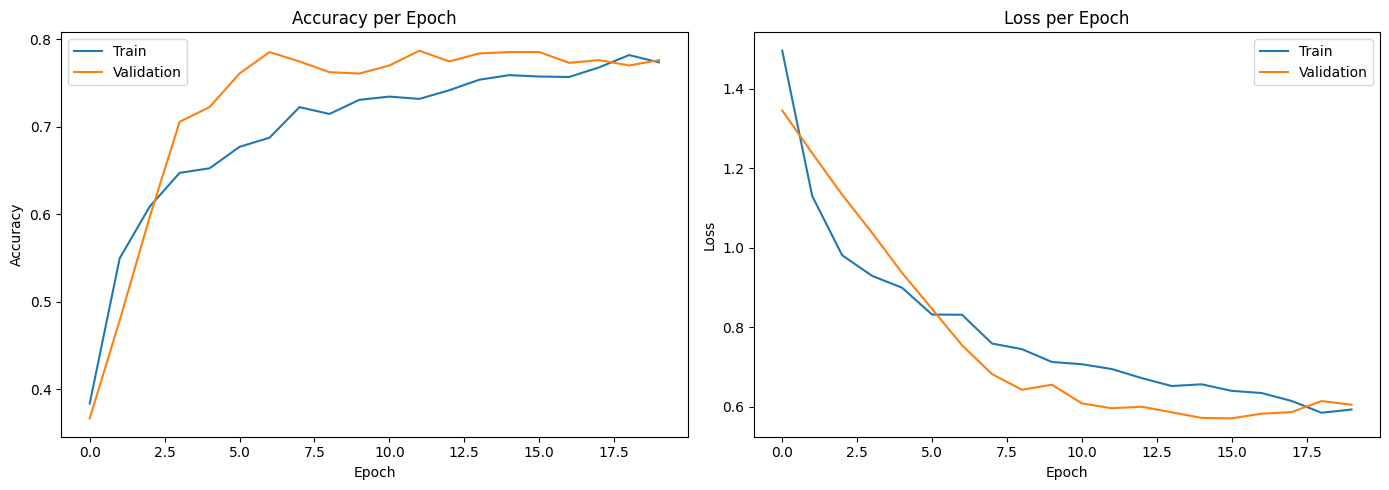

In [19]:
def plot_history(history, history_fine=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    acc     = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss     = history.history["loss"]
    val_loss = history.history["val_loss"]

    # Concatena as duas fases se houver fine-tuning
    if history_fine:
        acc     += history_fine.history["accuracy"]
        val_acc += history_fine.history["val_accuracy"]
        loss     += history_fine.history["loss"]
        val_loss += history_fine.history["val_loss"]

        # Linha vertical separando as fases
        fase1_epocas = len(history.history["accuracy"])
        axes[0].axvline(x=fase1_epocas, color="gray", linestyle="--")
        axes[1].axvline(x=fase1_epocas, color="gray", linestyle="--")

    axes[0].plot(acc,     label="Train")
    axes[0].plot(val_acc, label="Validation")
    axes[0].set_title("Accuracy per Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(loss,     label="Train")
    axes[1].plot(val_loss, label="Validation")
    axes[1].set_title("Loss per Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("/content/training_history.png", dpi=150)
    plt.show()

plot_history(history)

## 8-Avaliação Final no Conjunto de Teste


Acurácia no Teste: 0.8723 | Loss no Teste: 0.3673
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 208ms/step

Relatório de Classificação:
                  precision    recall  f1-score   support

    glioma_tumor       0.87      0.84      0.86       186
meningioma_tumor       0.87      0.74      0.80       188
        no_tumor       0.87      0.94      0.90        95
 pituitary_tumor       0.88      1.00      0.94       181

        accuracy                           0.87       650
       macro avg       0.87      0.88      0.87       650
    weighted avg       0.87      0.87      0.87       650



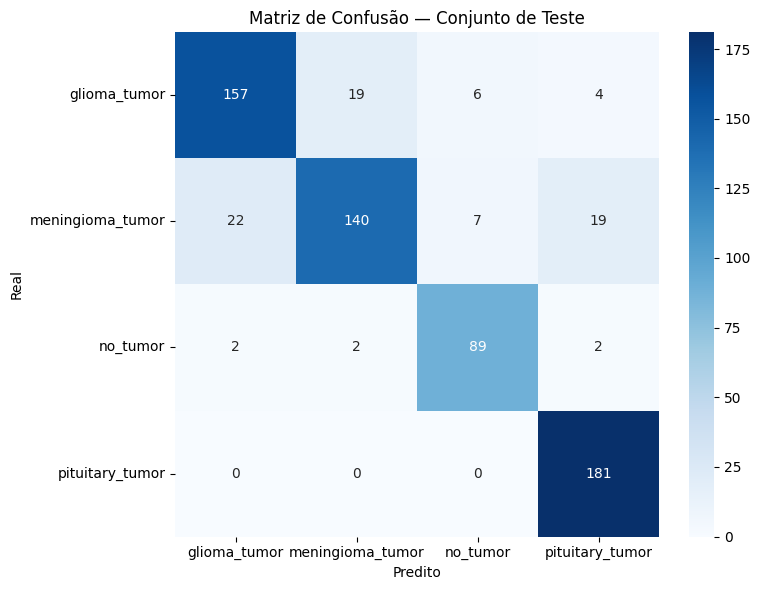

In [20]:
# Carrega o melhor modelo salvo
best_model = tf.keras.models.load_model("best_model.keras")

# Avalia no teste
test_loss, test_acc = best_model.evaluate(test_gen, verbose=0)
print(f"\nAcurácia no Teste: {test_acc:.4f} | Loss no Teste: {test_loss:.4f}")

# Predições
y_pred_proba = best_model.predict(test_gen)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = test_gen.classes

class_names = list(test_gen.class_indices.keys())

# Relatório detalhado
print("\nRelatório de Classificação:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Matriz de Confusão — Conjunto de Teste")
plt.ylabel("Real")
plt.xlabel("Predito")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()